# 🤝 Notebook 3: Collaborative Filtering

Approaches covered:

| Category | Methods |
|---|---|
| Memory-based – User | KNN, Pearson, Cosine |
| Memory-based – Item | KNN, Pearson, Cosine, Content-Enriched (TF-IDF & BoW) |
| Model-based | Matrix Factorisation (SGD), SVD (TruncatedSVD) |

All memory-based methods are **fully vectorised** (numpy batched matmul) — no Python loops over users or items.
Item-based Pearson and Cosine are derived purely from rating data, consistent with user-based methods.
Content-Enriched variants use TF-IDF / BoW similarity matrices from Notebook 2 as side features.

In [58]:
from pathlib import Path

# Paths
DATA_PATH   = "final_merged_dataset.csv"
FIGURES_DIR = Path("figures/cf")
MODELS_DIR  = Path("models/cf")
RESULTS_DIR = Path("results")

for d in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Imports
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

## 1. Load Data & Build Utility Matrix

In [59]:
from pathlib import Path

# Paths
DATA_PATH   = "final_merged_dataset.csv"
FIGURES_DIR = Path("figures/cf")
MODELS_DIR  = Path("models/cf")
RESULTS_DIR = Path("results")

for d in [FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Imports
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

## 2. Train/Test Split

In [60]:
np.random.seed(42)

train_rows, test_rows = [], []

for user, grp in ratings.groupby("user"):
    if len(grp) < 5:
        train_rows.append(grp)
        continue

    n_test = max(1, int(len(grp) * 0.2))
    test_idx = grp.sample(n=n_test, random_state=42).index

    train_rows.append(grp.drop(index=test_idx))
    test_rows.append(grp.loc[test_idx])

train_df = pd.concat(train_rows).reset_index(drop=True)
test_df  = pd.concat(test_rows).reset_index(drop=True)

print("Train:", len(train_df))
print("Test :", len(test_df))

Train: 195375
Test : 37484


In [61]:
train_utility = train_df.pivot_table(
    index="user",
    columns="item",
    values="rating"
)

train_utility.index = train_utility.index.astype(str)
train_utility.columns = train_utility.columns.astype(str)

print("Utility shape:", train_utility.shape)

sparsity = train_utility.isna().sum().sum() / train_utility.size
print(f"Sparsity: {sparsity:.2%}")

Utility shape: (33901, 118)
Sparsity: 95.12%


## 3. Helper: Evaluation Function

In [62]:
def evaluate_cf(predictions, test_df, train_df, all_courses,
                top_n=10, n_users=300, seed=42):

    rng = np.random.default_rng(seed)

    users = list(predictions.keys())
    users = rng.choice(users, min(n_users, len(users)), replace=False)

    hit, precision, recall = [], [], []
    y_true, y_pred = [], []

    for user in users:

        if user not in predictions:
            continue

        pred = predictions[user]

        # remove seen items
        seen = set(train_df[train_df["user"] == user]["item"])
        pred = pred.drop(index=list(seen), errors="ignore")

        if pred.empty:
            continue

        top_items = pred.sort_values(ascending=False).head(top_n)

        test_items = test_df[test_df["user"] == user]

        if len(test_items) == 0:
            continue

        test_set = set(test_items["item"])
        hits = set(top_items.index) & test_set

        hit.append(1 if hits else 0)
        precision.append(len(hits) / top_n)
        recall.append(len(hits) / len(test_set))

        # RMSE / MAE
        for _, row in test_items.iterrows():
            item = row["item"]
            if item in pred:
                y_true.append(row["rating"])
                y_pred.append(pred[item])

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)) if y_true else np.nan,
        "MAE": mean_absolute_error(y_true, y_pred) if y_true else np.nan,
        "HitRate@10": np.mean(hit) if hit else 0,
        "Precision@10": np.mean(precision) if precision else 0,
        "Recall@10": np.mean(recall) if recall else 0,
    }

## 4. Memory-Based: User-Based CF

### 4a. User-Based KNN

In [63]:
def user_knn_predictions(utility_matrix, k=20):
    """
    User-user KNN CF using cosine distance through sklearn KNN.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()
    mat = utility_matrix.fillna(0).values.astype(np.float32)

    knn = NearestNeighbors(
        n_neighbors=k+1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )
    knn.fit(mat)
    distances, indices = knn.kneighbors(mat)

    neighbor_idx = indices[:, 1:]
    neighbor_sims = (1 - distances[:, 1:]).astype(np.float32)

    neigh_ratings = mat[neighbor_idx]
    rated_mask = neigh_ratings > 0

    sims_exp = neighbor_sims[:, :, np.newaxis]
    wt_sum = (sims_exp * neigh_ratings).sum(axis=1)
    norm_sum = (sims_exp * rated_mask).sum(axis=1)

    pred_mat = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_mat[mat > 0] = 0

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing User-KNN predictions...")

pred_uknn = user_knn_predictions(train_utility, k=20)


with open(MODELS_DIR / "pred_user_knn.pkl", "wb") as f:
    pickle.dump(pred_uknn, f)

Computing User-KNN predictions...


In [64]:
import pickle
with open(MODELS_DIR / 'pred_user_knn.pkl', 'wb') as f:
    pickle.dump(pred_uknn, f)
print(f"Saved → {MODELS_DIR / 'pred_user_knn.pkl'}  ({len(pred_uknn):,} users)")


Saved → models/cf/pred_user_knn.pkl  (33,901 users)


### 4b. User-Based Pearson Correlation

In [65]:
def user_pearson_predictions(utility_matrix, k=20, batch_size=1000):
    """
    User-user CF using Pearson correlation.
    Pearson is cosine on mean-centered vectors.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()

    rated_mask = utility_matrix.notna().values
    raw = utility_matrix.fillna(0).values.astype(np.float32)

    row_sums = np.where(rated_mask, raw, 0).sum(axis=1, keepdims=True)
    row_counts = rated_mask.sum(axis=1, keepdims=True).clip(min=1)
    row_means = row_sums / row_counts
    centered = np.where(rated_mask, raw - row_means, 0).astype(np.float32)

    norms = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-9
    normed = (centered / norms).astype(np.float32)

    n = len(users)
    pred_mat = np.zeros_like(raw)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        sim_row = normed[start:end] @ normed.T
        sim_row[:, start:end] -= np.eye(end - start, dtype=np.float32) * 1e9

        top_k_idx = np.argpartition(-sim_row, k, axis=1)[:, :k]
        top_k_sims = np.take_along_axis(sim_row, top_k_idx, axis=1).clip(0)

        neigh_r = raw[top_k_idx]
        rated_m = neigh_r > 0

        sims_e = top_k_sims[:, :, np.newaxis]
        wt_sum = (sims_e * neigh_r).sum(axis=1)
        norm_sum = (sims_e * rated_m).sum(axis=1)

        pred_mat[start:end] = np.where(
            norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0
        )

    pred_mat[raw > 0] = 0

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing User-Pearson predictions...")

pred_upearson = user_pearson_predictions(train_utility, k=20, batch_size=1000)


with open(MODELS_DIR / "pred_user_pearson.pkl", "wb") as f:
    pickle.dump(pred_upearson, f)

Computing User-Pearson predictions...


### 4c. User-Based Cosine Similarity

In [66]:
def user_cosine_predictions(utility_matrix, k=20, batch_size=1000):
    """
    User-user CF using cosine similarity on mean-centered ratings.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()

    raw = utility_matrix.fillna(0).values.astype(np.float32)
    mean = raw.mean(axis=1, keepdims=True)
    centered = (raw - mean).astype(np.float32)

    norms = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-9
    normed = (centered / norms).astype(np.float32)

    n = len(users)
    pred_mat = np.zeros_like(raw)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        sim_row = normed[start:end] @ normed.T
        sim_row[:, start:end] -= np.eye(end - start, dtype=np.float32) * 1e9

        top_k_idx = np.argpartition(-sim_row, k, axis=1)[:, :k]
        top_k_sims = np.take_along_axis(sim_row, top_k_idx, axis=1).clip(0)

        neigh_r = raw[top_k_idx]
        rated_m = neigh_r > 0
        sims_e = top_k_sims[:, :, np.newaxis]

        wt_sum = (sims_e * neigh_r).sum(axis=1)
        norm_sum = (sims_e * rated_m).sum(axis=1)

        pred_mat[start:end] = np.where(
            norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0
        )

    pred_mat[raw > 0] = 0

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing User-Cosine predictions...")

pred_ucos = user_cosine_predictions(train_utility, k=20, batch_size=1000)


with open(MODELS_DIR / "pred_user_cosine.pkl", "wb") as f:
    pickle.dump(pred_ucos, f)

Computing User-Cosine predictions...


## 5. Memory-Based: Item-Based CF

### 5a. Item-Based KNN

In [67]:
def item_knn_predictions(utility_matrix, k=20):
    """
    Item-item KNN using cosine distance via sklearn.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()
    mat = utility_matrix.fillna(0).values.astype(np.float32)
    item_mat = mat.T

    knn = NearestNeighbors(
        n_neighbors=k+1,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1
    )
    knn.fit(item_mat)
    distances, indices = knn.kneighbors(item_mat)

    neigh_idx = indices[:, 1:]
    neigh_sims = (1 - distances[:, 1:]).astype(np.float32)

    neigh_ratings = mat.T[neigh_idx]
    rated_mask = neigh_ratings > 0

    sims_e = neigh_sims[:, :, np.newaxis]
    wt_sum = (sims_e * neigh_ratings).sum(axis=1)
    norm_sum = (sims_e * rated_mask).sum(axis=1)

    pred_item_user = np.where(
        norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0
    )
    pred_mat = pred_item_user.T
    pred_mat[mat > 0] = 0

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing Item-KNN predictions...")

pred_iknn = item_knn_predictions(train_utility, k=20)


with open(MODELS_DIR / "pred_item_knn.pkl", "wb") as f:
    pickle.dump(pred_iknn, f)

Computing Item-KNN predictions...


### 5b. Item-Based Pearson Correlation

In [68]:
def item_pearson_predictions(utility_matrix, k=20):
    """
    Item-item CF using Pearson correlation.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()
    mat = utility_matrix.fillna(0).values.astype(np.float32)

    item_mat = mat.T
    rated_mask = utility_matrix.notna().values.T

    row_sums = item_mat.sum(axis=1, keepdims=True)
    row_counts = rated_mask.sum(axis=1, keepdims=True).clip(min=1)
    item_means = row_sums / row_counts

    centered = np.where(rated_mask, item_mat - item_means, 0).astype(np.float32)

    norms = np.linalg.norm(centered, axis=1, keepdims=True) + 1e-9
    normed = centered / norms
    item_sim = (normed @ normed.T).astype(np.float32)
    np.fill_diagonal(item_sim, 0)

    top_k_idx = np.argpartition(-item_sim, k, axis=1)[:, :k]
    top_k_sims = np.take_along_axis(item_sim, top_k_idx, axis=1).clip(0)

    neigh_ratings = mat[:, top_k_idx]
    rated_m = neigh_ratings > 0
    sims_e = top_k_sims[np.newaxis, :, :]

    wt_sum = (sims_e * neigh_ratings).sum(axis=2)
    norm_sum = (sims_e * rated_m).sum(axis=2)

    pred_mat = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_mat[mat > 0] = 0

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing Item-Pearson predictions...")

pred_ipearson = item_pearson_predictions(train_utility, k=20)


with open(MODELS_DIR / "pred_item_pearson.pkl", "wb") as f:
    pickle.dump(pred_ipearson, f)

Computing Item-Pearson predictions...


### 5c. Item-Based Cosine Similarity

In [69]:
def item_cosine_predictions(utility_matrix, k=20):
    """
    Item-item CF using cosine similarity.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()
    mat = utility_matrix.fillna(0).values.astype(np.float32)

    item_sim = cosine_similarity(mat.T).astype(np.float32)
    np.fill_diagonal(item_sim, 0)

    top_k_idx = np.argpartition(-item_sim, k, axis=1)[:, :k]
    top_k_sims = np.take_along_axis(item_sim, top_k_idx, axis=1).clip(0)

    neigh_ratings = mat[:, top_k_idx]
    rated_m = neigh_ratings > 0
    sims_e = top_k_sims[np.newaxis, :, :]

    wt_sum = (sims_e * neigh_ratings).sum(axis=2)
    norm_sum = (sims_e * rated_m).sum(axis=2)

    pred_mat = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_mat[mat > 0] = 0

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing Item-Cosine predictions...")

pred_icos = item_cosine_predictions(train_utility, k=20)


with open(MODELS_DIR / "pred_item_cosine.pkl", "wb") as f:
    pickle.dump(pred_icos, f)

Computing Item-Cosine predictions...


### 5d. Item-Based Content-Enriched (TF-IDF & BoW)

Uses content similarity matrices from Notebook 2 as the item-item similarity source, combining content signals with user rating history.

In [70]:
def item_content_predictions(utility_matrix, item_sim_df, k=20):
    """
    Item-item CF using a precomputed content similarity matrix.
    """
    users = utility_matrix.index.tolist()
    items = utility_matrix.columns.tolist()
    mat = utility_matrix.fillna(0).values.astype(np.float32)

    common = [it for it in items if it in item_sim_df.index]
    common_idx = [items.index(it) for it in common]

    item_sim = item_sim_df.loc[common, common].values.astype(np.float32)
    np.fill_diagonal(item_sim, 0)

    if len(common) <= 1:
        return {
            user: pd.Series(np.zeros(len(items)), index=items)
            for user in users
        }

    k_eff = min(k, len(common) - 1)
    top_k_idx = np.argpartition(-item_sim, k_eff, axis=1)[:, :k_eff]
    top_k_sims = np.take_along_axis(item_sim, top_k_idx, axis=1).clip(0)

    mat_c = mat[:, common_idx]
    neigh_ratings = mat_c[:, top_k_idx]
    rated_m = neigh_ratings > 0
    sims_e = top_k_sims[np.newaxis, :, :]

    wt_sum = (sims_e * neigh_ratings).sum(axis=2)
    norm_sum = (sims_e * rated_m).sum(axis=2)

    pred_common = np.where(norm_sum > 0, wt_sum / (norm_sum + 1e-9), 0)
    pred_common[mat_c > 0] = 0

    pred_mat = np.zeros_like(mat)
    pred_mat[:, common_idx] = pred_common

    predictions = {
        user: pd.Series(pred_mat[i], index=items)
        for i, user in enumerate(users)
    }
    return predictions

print("Computing Item-Content (TF-IDF) predictions...")

pred_icontent_tfidf = item_content_predictions(train_utility, tfidf_cos_df, k=20)


print("Computing Item-Content (BoW) predictions...")

pred_icontent_bow = item_content_predictions(train_utility, bow_cos_df, k=20)


with open(MODELS_DIR / "pred_item_content_tfidf.pkl", "wb") as f:
    pickle.dump(pred_icontent_tfidf, f)

with open(MODELS_DIR / "pred_item_content_bow.pkl", "wb") as f:
    pickle.dump(pred_icontent_bow, f)

Computing Item-Content (TF-IDF) predictions...
Computing Item-Content (BoW) predictions...


## 6. Model-Based CF

### 6a. Matrix Factorisation (SGD)

In [71]:
class MatrixFactorization:
    """Biased MF via SGD."""
    def __init__(self, n_factors=20, lr=0.01, reg=0.02, n_epochs=20):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs

    def fit(self, ratings_df):
        self.users = list(ratings_df["user"].unique())
        self.items = list(ratings_df["item"].unique())

        u_idx = {u: i for i, u in enumerate(self.users)}
        i_idx = {it: j for j, it in enumerate(self.items)}

        n_u, n_i = len(self.users), len(self.items)

        self.mu = ratings_df["rating"].mean()
        self.bu = np.zeros(n_u)
        self.bi = np.zeros(n_i)
        self.P = np.random.normal(0, 0.1, (n_u, self.n_factors))
        self.Q = np.random.normal(0, 0.1, (n_i, self.n_factors))

        for epoch in range(self.n_epochs):
            total_loss = 0.0
            shuffled = ratings_df.sample(frac=1, random_state=epoch)

            for _, row in shuffled.iterrows():
                u = u_idx[row["user"]]
                i = i_idx[row["item"]]
                r = row["rating"]

                pred = self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]
                e = r - pred
                total_loss += e**2

                self.bu[u] += self.lr * (e - self.reg * self.bu[u])
                self.bi[i] += self.lr * (e - self.reg * self.bi[i])
                self.P[u] += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (e * self.P[u] - self.reg * self.Q[i])

            if (epoch + 1) % 5 == 0:
                rmse = np.sqrt(total_loss / len(ratings_df))
                print(f"Epoch {epoch+1:3d} RMSE: {rmse:.4f}")

        self.u_idx = u_idx
        self.i_idx = i_idx

    def predict_user(self, user, items):
        if user not in self.u_idx:
            return pd.Series(dtype=float)

        u = self.u_idx[user]
        preds = {}
        for item in items:
            i = self.i_idx.get(item)
            if i is None:
                continue
            preds[item] = float(
                self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]
            )
        return pd.Series(preds)

print("Training Matrix Factorization...")
mf_model = MatrixFactorization(n_factors=20, lr=0.01, reg=0.02, n_epochs=20)
mf_model.fit(train_df)
print("Done.")

mf_preds = {
    u: mf_model.predict_user(u, list(all_courses))
    for u in train_df["user"].unique()
}

with open(MODELS_DIR / "mf_model.pkl", "wb") as f:
    pickle.dump(mf_model, f)

with open(MODELS_DIR / "pred_mf.pkl", "wb") as f:
    pickle.dump(mf_preds, f)

Training Matrix Factorization...
Epoch   5 RMSE: 0.1642
Epoch  10 RMSE: 0.1530
Epoch  15 RMSE: 0.1438
Epoch  20 RMSE: 0.1356
Done.


## 7. Run All Evaluations

In [72]:
print("Evaluating all CF models...")

models = {
    "User-KNN": pred_uknn,
    "User-Pearson": pred_upearson,
    "User-Cosine": pred_ucos,
    "Item-KNN": pred_iknn,
    "Item-Pearson": pred_ipearson,
    "Item-Cosine": pred_icos,
    "Item-Content-TFIDF": pred_icontent_tfidf,
    "Item-Content-BoW": pred_icontent_bow,
    "MF": mf_preds
}

results_cf = {}

for name, preds in models.items():
    print("→", name)
    results_cf[name] = evaluate_cf(
        preds, test_df, train_df, all_courses, top_n=10, n_users=200
    )

results_cf_df = pd.DataFrame(results_cf).T.round(4)

print("\n=== Collaborative Filtering Evaluation Results ===")
print(results_cf_df.to_string())

Evaluating all CF models...
→ User-KNN
→ User-Pearson
→ User-Cosine
→ Item-KNN
→ Item-Pearson
→ Item-Cosine
→ Item-Content-TFIDF
→ Item-Content-BoW
→ MF

=== Collaborative Filtering Evaluation Results ===
                      RMSE     MAE  HitRate@10  Precision@10  Recall@10
User-KNN            1.3414  0.6082      0.6569        0.0781     0.5700
User-Pearson        2.9409  2.8894      0.1168        0.0131     0.0824
User-Cosine         1.5917  0.8510      0.6496        0.0781     0.5708
Item-KNN            0.0000  0.0000      0.3285        0.0387     0.2716
Item-Pearson        1.4412  0.6923      0.3212        0.0336     0.2540
Item-Cosine         0.0000  0.0000      0.2044        0.0219     0.1326
Item-Content-TFIDF  0.8057  0.2178      0.3212        0.0343     0.2681
Item-Content-BoW    0.8826  0.2614      0.2263        0.0234     0.1701
MF                  0.0569  0.0303      0.0730        0.0080     0.0512


## 8. Visualise CF Results

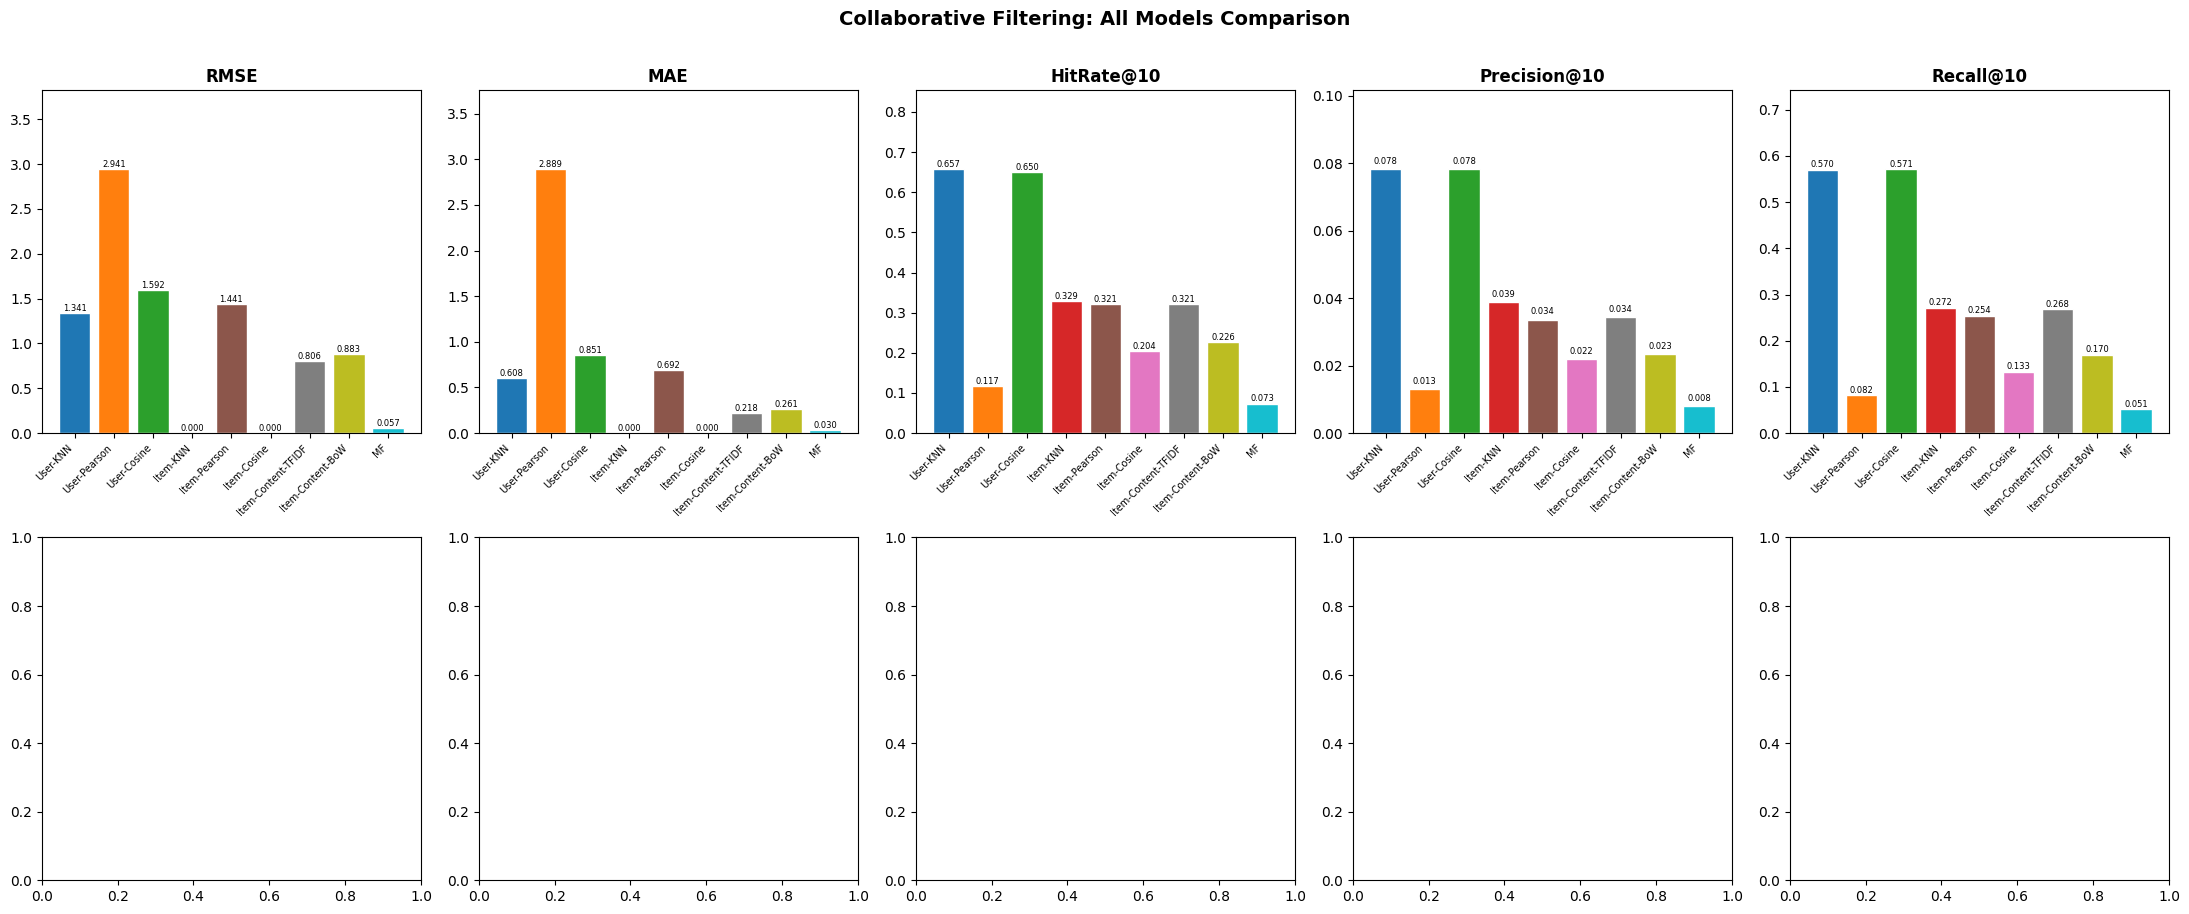

In [73]:
metrics = results_cf_df.columns.tolist()
n_models = len(results_cf_df)
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    vals = results_cf_df[metric]
    bars = ax.bar(range(n_models), vals, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(results_cf_df.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, vals.max() * 1.3 + 1e-6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6)

plt.suptitle('Collaborative Filtering: All Models Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_all_models_metrics.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Save Results

In [75]:
results_cf_df.to_csv(RESULTS_DIR / "results_collaborative_filtering.csv")
print(f"Saved results → {RESULTS_DIR / 'results_collaborative_filtering.csv'}")

train_df.to_csv(MODELS_DIR / "train_df.csv", index=False)
test_df.to_csv(MODELS_DIR / "test_df.csv", index=False)
print(f"Saved train/test splits → {MODELS_DIR}")

print("\n── Models saved in", MODELS_DIR, "──")
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(MODELS_DIR / f)
    print(f"  {f:30s}  {size/1024:8.1f} KB")

Saved results → results/results_collaborative_filtering.csv
Saved train/test splits → models/cf

── Models saved in models/cf ──
  mf_model.pkl                      6162.8 KB
  pred_item_content_bow.pkl        39122.6 KB
  pred_item_content_tfidf.pkl      39122.6 KB
  pred_item_cosine.pkl             39122.6 KB
  pred_item_knn.pkl                39122.6 KB
  pred_item_pearson.pkl            39122.6 KB
  pred_mf.pkl                      54750.9 KB
  pred_user_cosine.pkl             39122.6 KB
  pred_user_knn.pkl                39122.6 KB
  pred_user_pearson.pkl            39122.6 KB
  test_df.csv                        753.1 KB
  train_df.csv                      3923.0 KB
